# FIFA World Cup 2026 — Analytic Task: Forward Goal Involvement

**Author:** Shreejan Shrestha (Shriz) — CDU Master of Software Engineering, HIT140 Foundations of Data Science (S226), Assessment 2
**Individual analytic task 4 of 4:** forward player analysis

**Analytic question:** Among forward players (`position == "FWD"`) registered in FIFA World Cup 2026 squads, is there a statistically significant difference in average goal involvement (goals + assists) between forwards whose teams advanced to the knockout stage versus forwards whose teams were eliminated in the group stage?

**Folder structure:** this notebook lives in `notebooks/`; source data is in `../data/raw/`, the drawn sample is saved to `../data/processed/`, and figures are saved to `../figures/`.

**Data source:** FIFA World Cup 2026 relational dataset ([github.com/mominullptr/FIFA-World-Cup-2026-Dataset](https://github.com/mominullptr/FIFA-World-Cup-2026-Dataset), CC0), built from FIFA.com / Sofascore / FBref. Cross-checked against independent post-tournament reporting (final/semifinal scores, Golden Boot standings). The four required tables are **downloaded automatically** into `data/raw/` if not already present, pinned to a fixed commit for exact reproducibility.

**Limitation:** the dataset does not record minutes played per player, so squad members who never appeared in a match cannot be excluded. We treat all 313 registered WC2026 forwards as the target population.

**Robustness check:** knockout-stage teams play more matches than teams eliminated in the group stage (up to 8 vs. exactly 3), so a raw-count comparison is confounded with "more matches = more chances to score." Section 6 re-runs the test on a per-match rate to check whether the effect holds up once that's controlled for.

*Run all cells top to bottom. No manual file setup required — Section 0 fetches the data automatically if it isn't already in `../data/raw/`.*

In [1]:
import urllib.request
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

RANDOM_STATE = 42  # fixed seed -> reproducible sample for the report/repo

# This notebook lives in <project_root>/notebooks/. Data and outputs
# live in sibling folders (data/raw, data/processed, figures), not
# next to the notebook itself.
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
for _d in (RAW_DIR, PROCESSED_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

## 0. Data Acquisition (semi-automated)
Download the four required CSVs into `data/raw/` if they aren't already there, pinned to a fixed commit so results stay reproducible even if the upstream dataset is updated later.

In [2]:
DATASET_COMMIT = "2f61805ec8ac58e52882e8f0e2413a5cfa7f4d61"
BASE_URL = f"https://raw.githubusercontent.com/mominullptr/FIFA-World-Cup-2026-Dataset/{DATASET_COMMIT}/"
REQUIRED_FILES = ["squads_and_players.csv", "match_events.csv", "matches.csv", "tournament_stages.csv"]

def ensure_data_files(data_dir: Path) -> None:
    for fname in REQUIRED_FILES:
        fpath = data_dir / fname
        if fpath.exists():
            continue
        print(f"'{fname}' not found in {data_dir} - downloading from source repo (pinned commit)...")
        try:
            urllib.request.urlretrieve(BASE_URL + fname, fpath)
            print(f"  saved to {fpath}")
        except Exception as exc:
            raise FileNotFoundError(
                f"Could not find '{fname}' locally and could not download it "
                f"({exc}). Place it in {data_dir} manually and re-run."
            ) from exc

ensure_data_files(RAW_DIR)

## 1. Data Wrangling
Obtain player details and match-event history; build the two variables the question needs: whether a player's team reached the knockout stage, and their goal involvements.

In [3]:
players = pd.read_csv(RAW_DIR / "squads_and_players.csv")
events = pd.read_csv(RAW_DIR / "match_events.csv")
matches = pd.read_csv(RAW_DIR / "matches.csv")
stages = pd.read_csv(RAW_DIR / "tournament_stages.csv")

forwards = players[players["position"] == "FWD"].copy()

knockout_stage_ids = stages.loc[stages["is_knockout"], "stage_id"]
ko_matches = matches[matches["stage_id"].isin(knockout_stage_ids)]
knockout_team_ids = set(ko_matches["home_team_id"]) | set(ko_matches["away_team_id"])
forwards["reached_knockout"] = forwards["team_id"].isin(knockout_team_ids)

goal_involvements = (
    events[events["event_type"].isin(["Goal", "Assist"])]
    .groupby("player_id")
    .size()
    .rename("goal_involvements")
)
forwards = forwards.merge(goal_involvements, left_on="player_id", right_index=True, how="left")
forwards["goal_involvements"] = forwards["goal_involvements"].fillna(0).astype(int)

# Engineered variable: matches played by each player's team, used later
# to build a per-match rate that controls for "knockout teams play more games"
team_appearances = pd.concat([
    matches[["home_team_id"]].rename(columns={"home_team_id": "team_id"}),
    matches[["away_team_id"]].rename(columns={"away_team_id": "team_id"}),
])
team_matches_played = team_appearances.value_counts("team_id").rename("team_matches_played")
forwards = forwards.merge(team_matches_played, left_on="team_id", right_index=True, how="left")
forwards["involvement_rate"] = forwards["goal_involvements"] / forwards["team_matches_played"]

forwards = forwards[["player_id", "player_name", "team_id", "reached_knockout",
                      "team_matches_played", "goal_involvements", "involvement_rate"]]

print(f"POPULATION: all registered WC2026 forwards, N = {len(forwards)}")
forwards["reached_knockout"].value_counts().rename({True: "Reached knockout", False: "Eliminated in groups"})

POPULATION: all registered WC2026 forwards, N = 313


reached_knockout
Reached knockout        213
Eliminated in groups    100
Name: count, dtype: int64

## 2. Data Preparation and Sampling
Population = all 313 registered forwards. Sample = stratified random sample (60% from each group), so both groups are proportionally represented and large enough (n > 30 per group) for the CLT to justify a t-based test.

In [4]:
sample = pd.concat(
    [g.sample(frac=0.6, random_state=RANDOM_STATE) for _, g in forwards.groupby("reached_knockout")],
    ignore_index=True,
)

sample_ko = sample.loc[sample["reached_knockout"], "goal_involvements"]
sample_out = sample.loc[~sample["reached_knockout"], "goal_involvements"]
rate_ko = sample.loc[sample["reached_knockout"], "involvement_rate"]
rate_out = sample.loc[~sample["reached_knockout"], "involvement_rate"]

print(f"SAMPLE: stratified random sample, 60% of each group, N = {len(sample)}  "
      f"(knockout={len(sample_ko)}, eliminated-in-groups={len(sample_out)})")

sample.to_csv(PROCESSED_DIR / "sample_forward_goal_involvement.csv", index=False)
sample.head()

SAMPLE: stratified random sample, 60% of each group, N = 188  (knockout=128, eliminated-in-groups=60)


,player_id,player_name,team_id,reached_knockout,team_matches_played,goal_involvements,involvement_rate
0,897,Yousif Hashim Ali Yousif,35,False,3,0,0.0
1,606,Elias Saad,24,False,3,0,0.0
2,790,Mohammed Salem Aldawsari,31,False,3,0,0.0
3,453,Jeremy Cornelis Jacobus Antonisse,18,False,3,0,0.0
4,451,Jürgen Leonardo Locadia,18,False,3,0,0.0


## 3. Descriptive Statistics
One self-explanatory figure: (A) who's in the analysis — population vs. stratified sample by group, (B) what the raw data looks like and why the median is 0, (C) the group comparison itself with n and mean annotated directly on the chart.

Overall sample - goal involvements (n=188)
  mean   = 0.947
  median = 0.000
  std    = 1.915
  min/max= 0 / 14

Knockout-stage forwards (n=128)
  mean   = 1.305
  median = 0.000
  std    = 2.211
  min/max= 0 / 14

Group-stage-eliminated forwards (n=60)
  mean   = 0.183
  median = 0.000
  std    = 0.469
  min/max= 0 / 2



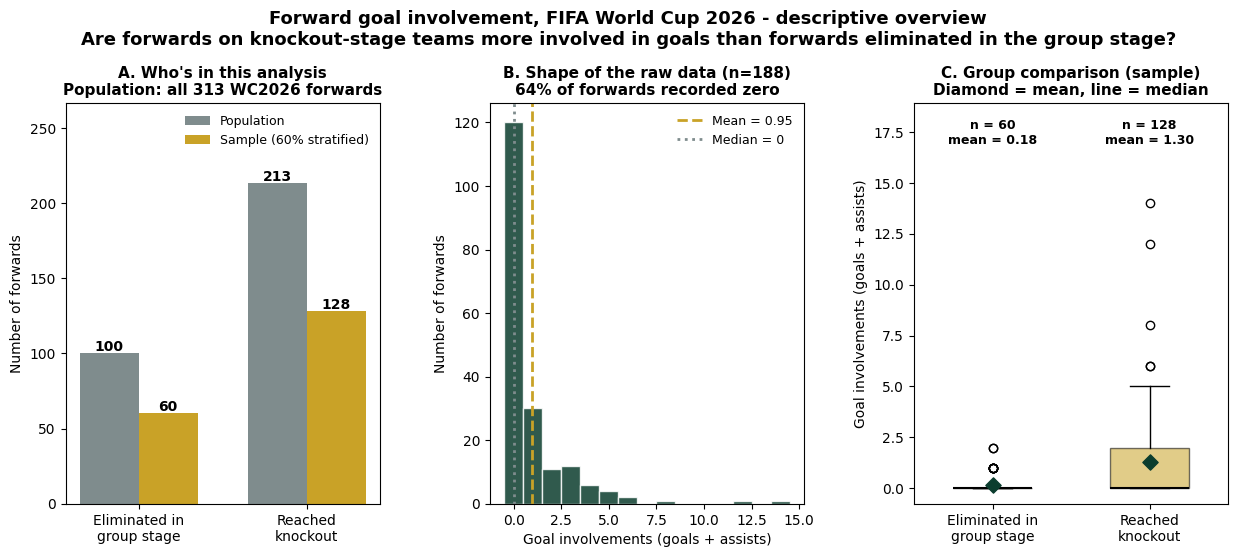

In [5]:
def describe(series, label):
    print(f"{label} (n={len(series)})")
    print(f"  mean   = {series.mean():.3f}")
    print(f"  median = {series.median():.3f}")
    print(f"  std    = {series.std(ddof=1):.3f}")
    print(f"  min/max= {series.min()} / {series.max()}\n")

describe(sample["goal_involvements"], "Overall sample - goal involvements")
describe(sample_ko, "Knockout-stage forwards")
describe(sample_out, "Group-stage-eliminated forwards")

GREEN, GOLD, GREY = "#0B3D2E", "#C9A227", "#7f8c8d"
labels = ["Eliminated in\ngroup stage", "Reached\nknockout"]

fig1 = plt.figure(figsize=(15, 5.2))
gs = fig1.add_gridspec(1, 3, wspace=0.35)

# Panel A: population -> sample, by group
axA = fig1.add_subplot(gs[0, 0])
pop_counts = forwards["reached_knockout"].value_counts()
samp_counts = sample["reached_knockout"].value_counts()
pop_vals = [pop_counts.get(False, 0), pop_counts.get(True, 0)]
samp_vals = [samp_counts.get(False, 0), samp_counts.get(True, 0)]
xpos = np.arange(2)
w = 0.35
for bars in (axA.bar(xpos - w/2, pop_vals, w, label="Population", color=GREY),
             axA.bar(xpos + w/2, samp_vals, w, label="Sample (60% stratified)", color=GOLD)):
    for bar in bars:
        h = bar.get_height()
        axA.annotate(f"{int(h)}", (bar.get_x() + bar.get_width()/2, h), ha="center",
                     va="bottom", fontsize=10, fontweight="bold")
axA.set_xticks(xpos)
axA.set_xticklabels(labels)
axA.set_ylabel("Number of forwards")
axA.set_title("A. Who's in this analysis\nPopulation: all %d WC2026 forwards" % len(forwards),
               fontsize=11, fontweight="bold")
axA.legend(loc="upper right", fontsize=9, frameon=False)
axA.set_ylim(0, max(pop_vals) * 1.25)

# Panel B: shape of the raw data (explains why the median is 0)
axB = fig1.add_subplot(gs[0, 1])
bins = np.arange(0, sample["goal_involvements"].max() + 2) - 0.5
axB.hist(sample["goal_involvements"], bins=bins, color=GREEN, edgecolor="white", alpha=0.85)
mean_val, median_val = sample["goal_involvements"].mean(), sample["goal_involvements"].median()
axB.axvline(mean_val, color=GOLD, linewidth=2, linestyle="--", label=f"Mean = {mean_val:.2f}")
axB.axvline(median_val, color=GREY, linewidth=2, linestyle=":", label=f"Median = {median_val:.0f}")
pct_zero = (sample["goal_involvements"] == 0).mean() * 100
axB.set_xlabel("Goal involvements (goals + assists)")
axB.set_ylabel("Number of forwards")
axB.set_title(f"B. Shape of the raw data (n={len(sample)})\n{pct_zero:.0f}% of forwards recorded zero",
              fontsize=11, fontweight="bold")
axB.legend(loc="upper right", fontsize=9, frameon=False)

# Panel C: the group comparison itself, annotated
axC = fig1.add_subplot(gs[0, 2])
bp = axC.boxplot([sample_out, sample_ko], tick_labels=labels, patch_artist=True, widths=0.5,
                  medianprops=dict(color="black", linewidth=1.5))
for patch, color in zip(bp["boxes"], [GREY, GOLD]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
axC.scatter([1, 2], [sample_out.mean(), sample_ko.mean()], marker="D", color=GREEN, s=60, zorder=5)
top = max(sample_ko.max(), sample_out.max()) * 1.35
axC.set_ylim(-top * 0.04, top)
for i, (n_, m_) in enumerate(zip([len(sample_out), len(sample_ko)],
                                  [sample_out.mean(), sample_ko.mean()]), start=1):
    axC.annotate(f"n = {n_}\nmean = {m_:.2f}", (i, top * 0.96), ha="center", va="top",
                 fontsize=9, fontweight="bold")
axC.set_ylabel("Goal involvements (goals + assists)")
axC.set_title("C. Group comparison (sample)\nDiamond = mean, line = median", fontsize=11, fontweight="bold")

fig1.suptitle(
    "Forward goal involvement, FIFA World Cup 2026 - descriptive overview\n"
    "Are forwards on knockout-stage teams more involved in goals than forwards eliminated in the group stage?",
    fontsize=13, fontweight="bold", y=1.06,
)
fig1.savefig(FIGURES_DIR / "descriptive_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Inferential Statistics — Confidence Interval
95% CI for the true population mean goal involvement of WC2026 forwards, estimated from the sample (t-distribution, since the population standard deviation is unknown). Also computed per group, for use in the results figure in Section 7.

In [6]:
def ci95(series):
    n = len(series)
    return stats.t.interval(confidence=0.95, df=n - 1, loc=series.mean(), scale=series.sem())

n = len(sample)
mean = sample["goal_involvements"].mean()
ci_low, ci_high = ci95(sample["goal_involvements"])

print(f"Sample mean = {mean:.3f}")
print(f"95% CI for population mean goal involvement (all WC2026 forwards) = [{ci_low:.3f}, {ci_high:.3f}]")

ci_ko_low, ci_ko_high = ci95(sample_ko)
ci_out_low, ci_out_high = ci95(sample_out)
ci_rate_ko_low, ci_rate_ko_high = ci95(rate_ko)
ci_rate_out_low, ci_rate_out_high = ci95(rate_out)

print(f"knockout group 95% CI   = [{ci_ko_low:.3f}, {ci_ko_high:.3f}]")
print(f"eliminated group 95% CI = [{ci_out_low:.3f}, {ci_out_high:.3f}]")

Sample mean = 0.947
95% CI for population mean goal involvement (all WC2026 forwards) = [0.671, 1.222]
knockout group 95% CI   = [0.918, 1.691]
eliminated group 95% CI = [0.062, 0.305]


## 5. Inferential Statistics — Two-Sample t-test

H0: mean goal involvement is equal for knockout vs. eliminated forwards. H1: the means differ.

Welch's t-test (unequal variances) is used since the two groups' variances differ substantially — eliminated forwards rarely score, so their variance is much smaller.

In [7]:
t_stat, p_value = stats.ttest_ind(sample_ko, sample_out, equal_var=False)
alpha = 0.05

print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.6f}")
if p_value < alpha:
    print(f"p < {alpha} -> reject H0. Statistically significant difference in mean goal "
          f"involvement between forwards on knockout-stage teams and forwards eliminated "
          f"in the group stage.")
else:
    print(f"p >= {alpha} -> fail to reject H0. No statistically significant difference detected.")

t-statistic = 5.480, p-value = 0.000000
p < 0.05 -> reject H0. Statistically significant difference in mean goal involvement between forwards on knockout-stage teams and forwards eliminated in the group stage.


## 6. Robustness Check — Per-Match Involvement Rate

Re-run the comparison on `involvement_rate` (goal involvements per team match played) instead of the raw count, to check whether the result above is just an artefact of knockout teams playing more matches.

In [8]:
describe(rate_ko, "Knockout-stage forwards - involvement RATE (per team match)")
describe(rate_out, "Eliminated-in-groups forwards - involvement RATE (per team match)")

t_rate, p_rate = stats.ttest_ind(rate_ko, rate_out, equal_var=False)
print(f"Welch's t-test on involvement_rate: t = {t_rate:.3f}, p = {p_rate:.6f}")
if p_rate < alpha:
    print("Still significant after controlling for matches played -> the effect is not "
          "merely 'knockout teams play more games'; forwards on knockout teams are more "
          "productive on a PER-MATCH basis too.")
else:
    print("Not significant once matches played is controlled for -> the raw-count effect "
          "above may be largely driven by knockout teams simply playing more matches.")

Knockout-stage forwards - involvement RATE (per team match) (n=128)
  mean   = 0.236
  median = 0.000
  std    = 0.352
  min/max= 0.0 / 1.75

Eliminated-in-groups forwards - involvement RATE (per team match) (n=60)
  mean   = 0.061
  median = 0.000
  std    = 0.156
  min/max= 0.0 / 0.6666666666666666

Welch's t-test on involvement_rate: t = 4.712, p = 0.000005
Still significant after controlling for matches played -> the effect is not merely 'knockout teams play more games'; forwards on knockout teams are more productive on a PER-MATCH basis too.


## 7. Results Figure — Group Means with 95% CI
A visual companion to Sections 4–6: group means for both the raw count and the per-match rate, each with its own 95% CI error bars, so the separation between groups is visible at a glance.

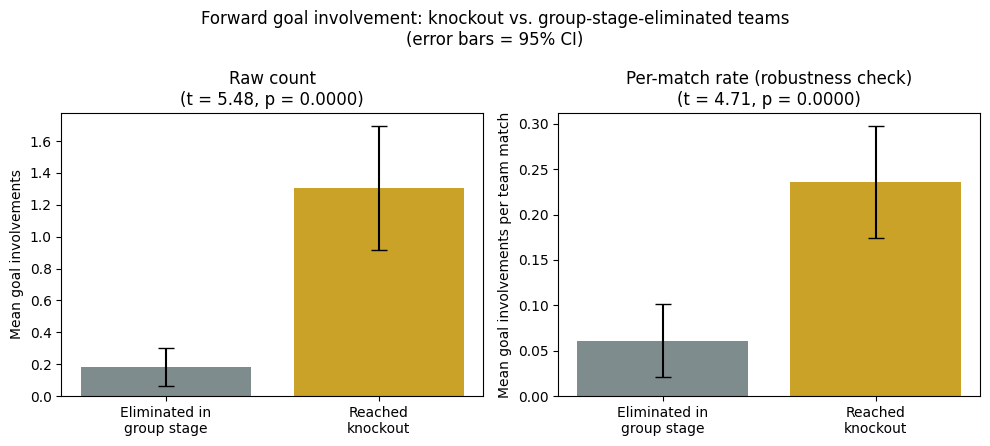

In [9]:
fig2, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.5))
groups = ["Eliminated in\ngroup stage", "Reached\nknockout"]

means_count = [sample_out.mean(), sample_ko.mean()]
err_count = [
    [sample_out.mean() - ci_out_low, sample_ko.mean() - ci_ko_low],
    [ci_out_high - sample_out.mean(), ci_ko_high - sample_ko.mean()],
]
axL.bar(groups, means_count, color=["#7f8c8d", "#c9a227"], yerr=err_count, capsize=6)
axL.set_ylabel("Mean goal involvements")
axL.set_title("Raw count\n(t = %.2f, p = %.4f)" % (t_stat, p_value))

means_rate = [rate_out.mean(), rate_ko.mean()]
err_rate = [
    [rate_out.mean() - ci_rate_out_low, rate_ko.mean() - ci_rate_ko_low],
    [ci_rate_out_high - rate_out.mean(), ci_rate_ko_high - rate_ko.mean()],
]
axR.bar(groups, means_rate, color=["#7f8c8d", "#c9a227"], yerr=err_rate, capsize=6)
axR.set_ylabel("Mean goal involvements per team match")
axR.set_title("Per-match rate (robustness check)\n(t = %.2f, p = %.4f)" % (t_rate, p_rate))

fig2.suptitle("Forward goal involvement: knockout vs. group-stage-eliminated teams\n(error bars = 95% CI)")
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "results_comparison.png", dpi=150)
plt.show()